# Star Rating Modeling

You are trying to predict the exact rating from review text, so the notebook needs to stay readable from start to finish. The structure below walks through the dataset, the baselines, the classical models, the neural models, and the final comparison in a way that is easier to follow when you come back later.

## Installing `gensim`

You need `gensim` for the Word2Vec baseline used later. If the package is already available in your environment, this step is just a quick dependency check.

In [2]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.3 MB/s eta 0:00:00


## Setting up the workspace

You import the libraries for data handling, visualization, classical machine learning, neural models, and reproducibility. Fixing the random seed here makes the comparisons more stable and helps you reproduce the same split and the same training behavior.

In [3]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


## Loading the cleaned dataset

You read the cleaned CSV and keep only the fields that matter for rating prediction. Splitting `train` and `test` at this stage makes the rest of the notebook safer because the unlabeled official test rows stay out of model fitting.

In [4]:
df = pd.read_csv("dataset_cleaned.csv")

useful_columns = ["note", "type", "avis_en_tfidf_lda", "avis_en_embeddings"]
df_model = df[useful_columns].copy()
df_model["type"] = df_model["type"].astype(str).str.lower().str.strip()
df_model["avis_en_tfidf_lda"] = df_model["avis_en_tfidf_lda"].fillna("").astype(str)
df_model["avis_en_embeddings"] = df_model["avis_en_embeddings"].fillna("").astype(str)

train_df = df_model[(df_model["type"] == "train") & (df_model["note"].notna())].copy()
test_df = df_model[df_model["type"] == "test"].copy()
train_df["note"] = train_df["note"].astype(int)


## Checking what the training data looks like

You verify the dataset size, the rating balance, and the review-length distribution before training anything. That quick sanity check tells you whether the task is imbalanced and whether some models may struggle with very short or very long reviews.

Full dataset shape: (3000, 16)
Labelled train rows: (2000, 4)
Unlabelled official test rows: (1000, 4)
Rating distribution in train:
note
1    638
2    313
3    259
4    411
5    379
Name: count, dtype: int64


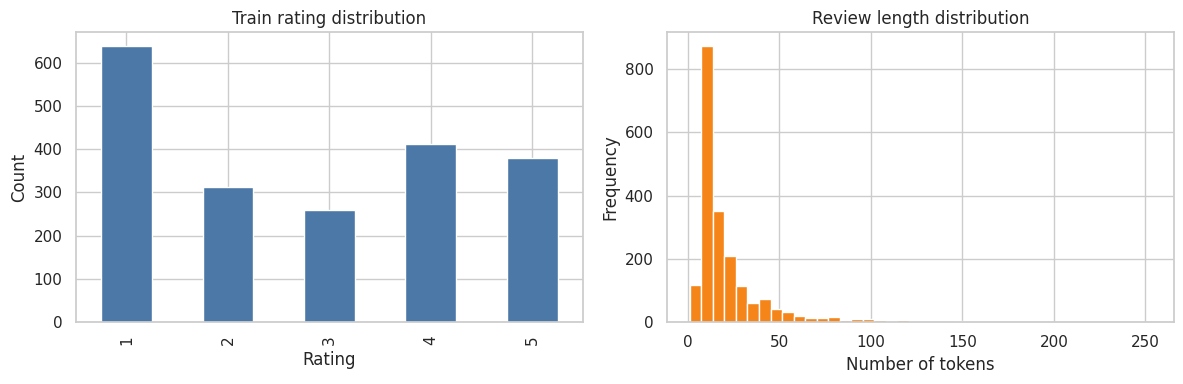

In [5]:
print("Full dataset shape:", df.shape)
print("Labelled train rows:", train_df.shape)
print("Unlabelled official test rows:", test_df.shape)
print("Rating distribution in train:")
print(train_df["note"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df["note"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set_title("Train rating distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

train_df["avis_en_tfidf_lda"].str.split().map(len).plot(kind="hist", bins=40, ax=axes[1], color="#f58518")
axes[1].set_title("Review length distribution")
axes[1].set_xlabel("Number of tokens")

plt.tight_layout()
plt.show()


## Creating one shared validation split

You build a single stratified validation split and reuse it across every model. That choice is important because it keeps the benchmark fair: a strong score only means something if every approach is evaluated on the same rows.

In [6]:
X_tfidf = train_df["avis_en_tfidf_lda"].copy()
X_embed = train_df["avis_en_embeddings"].copy()
y = train_df["note"].copy()

train_idx, valid_idx = train_test_split(
    train_df.index,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

X_train_tfidf = X_tfidf.loc[train_idx]
X_valid_tfidf = X_tfidf.loc[valid_idx]
X_train_embed = X_embed.loc[train_idx]
X_valid_embed = X_embed.loc[valid_idx]
y_train = y.loc[train_idx]
y_valid = y.loc[valid_idx]

print(X_train_tfidf.shape, X_valid_tfidf.shape)
print("Train distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("Validation distribution:")
print(y_valid.value_counts(normalize=True).sort_index().round(3))


(1600,) (400,)
Train distribution:
note
1    0.319
2    0.156
3    0.129
4    0.206
5    0.189
Name: proportion, dtype: float64
Validation distribution:
note
1    0.318
2    0.158
3    0.130
4    0.205
5    0.190
Name: proportion, dtype: float64


## Defining the evaluation tools

You centralize the metrics and the reporting helpers so the notebook stays consistent. Keeping regression and classification evaluation in one place makes the final comparison much cleaner and reduces the risk of scoring models in slightly different ways.

In [7]:
RATING_ORDER = [1, 2, 3, 4, 5]
results_regression = []
results_classification = []


def evaluate_regression(model_name, y_true, y_pred):
    metrics = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }
    result = pd.DataFrame([metrics])
    results_regression.append(result)
    return result



def evaluate_classification(model_name, y_true, y_pred):
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted"),
    }
    result = pd.DataFrame([metrics])
    results_classification.append(result)
    cm = confusion_matrix(y_true, y_pred, labels=RATING_ORDER)
    return result, cm



def show_report(y_true, y_pred):
    print(classification_report(y_true, y_pred, labels=RATING_ORDER, zero_division=0))



def show_confusion_matrix(y_true, y_pred, title):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_true, y_pred, labels=RATING_ORDER),
        display_labels=RATING_ORDER,
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()


## Starting with simple baselines

You measure how far a naive predictor can already go before trusting more complex models. If a sophisticated model barely beats the mean regressor or the majority classifier, that usually means the extra complexity is not buying much.

In [8]:
mean_baseline = DummyRegressor(strategy="mean")
mean_baseline.fit(np.zeros((len(y_train), 1)), y_train)
y_pred_mean = mean_baseline.predict(np.zeros((len(y_valid), 1)))
results_mean_reg = evaluate_regression("Baseline Mean Regressor", y_valid, y_pred_mean)

majority_baseline = DummyClassifier(strategy="most_frequent")
majority_baseline.fit(np.zeros((len(y_train), 1)), y_train)
y_pred_majority = majority_baseline.predict(np.zeros((len(y_valid), 1)))
results_majority, cm_majority = evaluate_classification("Baseline Majority Class", y_valid, y_pred_majority)

results_mean_reg, results_majority


(                     Model       MAE      RMSE        R2
 0  Baseline Mean Regressor  1.388031  1.532793 -0.000004,
                      Model  Accuracy  Macro_F1  Weighted_F1
 0  Baseline Majority Class    0.3175  0.096395     0.153027)

## Training a TF-IDF Ridge regressor

You first treat the rating as a continuous target and let a linear regressor learn from sparse n-gram features. This is a useful reference point because it often captures overall sentiment intensity surprisingly well, even when it does not predict the exact class perfectly.

In [9]:
ridge_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        ("reg", Ridge(alpha=1.0)),
    ]
)

ridge_tfidf.fit(X_train_tfidf, y_train)
y_pred_ridge_tfidf = ridge_tfidf.predict(X_valid_tfidf)
results_ridge_tfidf = evaluate_regression("TF-IDF + Ridge", y_valid, y_pred_ridge_tfidf)
results_ridge_tfidf


,Model,MAE,RMSE,R2
0,TF-IDF + Ridge,0.795797,0.98006,0.591172


## Training a TF-IDF Logistic Regression classifier

You switch to direct 5-class prediction with a strong classical text baseline. Logistic Regression is fast, interpretable, and often hard to beat on structured bag-of-words text, especially when the preprocessing is already solid.

In [10]:
logreg_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=4000,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)

logreg_tfidf.fit(X_train_tfidf, y_train)
y_pred_logreg_tfidf = logreg_tfidf.predict(X_valid_tfidf)
results_logreg_tfidf, cm_logreg_tfidf = evaluate_classification(
    "TF-IDF + Logistic Regression", y_valid, y_pred_logreg_tfidf
)
results_logreg_tfidf


,Model,Accuracy,Macro_F1,Weighted_F1
0,TF-IDF + Logistic Regression,0.4675,0.410242,0.457621


## Looking at the TF-IDF Logistic Regression errors

You inspect the detailed classification report and the confusion matrix to see where the model hesitates. The most interesting part is usually whether it mostly confuses neighboring ratings or whether it collapses several classes together.

              precision    recall  f1-score   support

           1       0.60      0.66      0.63       127
           2       0.30      0.35      0.32        63
           3       0.21      0.12      0.15        52
           4       0.45      0.45      0.45        82
           5       0.49      0.50      0.50        76

    accuracy                           0.47       400
   macro avg       0.41      0.42      0.41       400
weighted avg       0.45      0.47      0.46       400



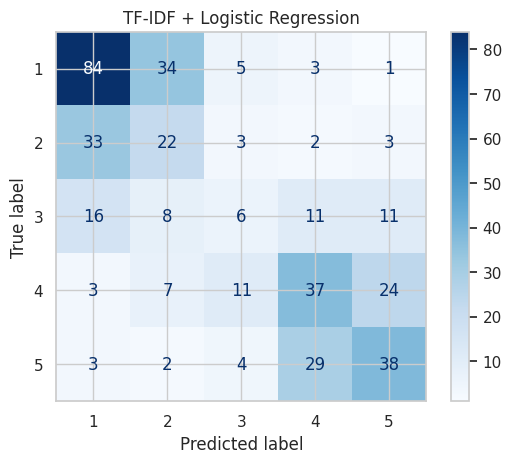

In [11]:
show_report(y_valid, y_pred_logreg_tfidf)
show_confusion_matrix(y_valid, y_pred_logreg_tfidf, "TF-IDF + Logistic Regression")


## Training a TF-IDF Linear SVM

You add another classic sparse-text model that often performs very well on high-dimensional features. Comparing it with Logistic Regression tells you whether the task benefits more from margin-based separation or from probabilistic linear classification.

In [12]:
svm_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        ("clf", LinearSVC(class_weight="balanced", random_state=SEED)),
    ]
)

svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svm_tfidf = svm_tfidf.predict(X_valid_tfidf)
results_svm_tfidf, cm_svm_tfidf = evaluate_classification(
    "TF-IDF + Linear SVM", y_valid, y_pred_svm_tfidf
)
results_svm_tfidf


,Model,Accuracy,Macro_F1,Weighted_F1
0,TF-IDF + Linear SVM,0.46,0.379374,0.437331


## Reading the Linear SVM behavior

You check the same error patterns for the SVM so the comparison stays honest. The confusion matrix helps you see whether the gain, if any, comes from better handling minority ratings or simply from stronger performance on the dominant classes.

              precision    recall  f1-score   support

           1       0.60      0.76      0.67       127
           2       0.29      0.24      0.26        63
           3       0.15      0.08      0.10        52
           4       0.39      0.40      0.40        82
           5       0.46      0.47      0.46        76

    accuracy                           0.46       400
   macro avg       0.38      0.39      0.38       400
weighted avg       0.42      0.46      0.44       400



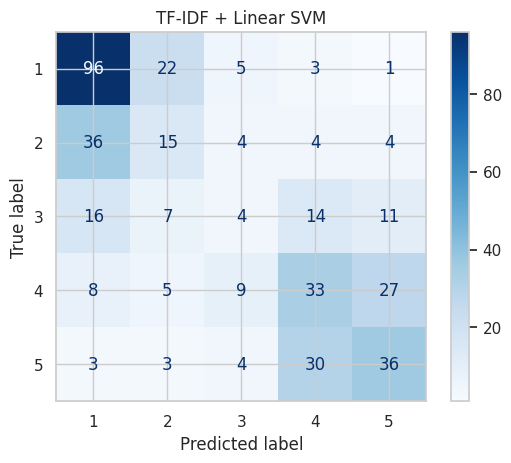

In [13]:
show_report(y_valid, y_pred_svm_tfidf)
show_confusion_matrix(y_valid, y_pred_svm_tfidf, "TF-IDF + Linear SVM")


## Building averaged Word2Vec document vectors

You create dense document embeddings by averaging word vectors learned on the training reviews. This gives you a lighter semantic baseline than transformers, but it also throws away word order and can smooth out subtle differences between close ratings.

In [14]:
X_train_tokens = [text.split() for text in X_train_embed.tolist()]
X_valid_tokens = [text.split() for text in X_valid_embed.tolist()]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=SEED,
)


def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_train_tokens])
X_valid_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_valid_tokens])

print(X_train_w2v.shape, X_valid_w2v.shape)


(1600, 100) (400, 100)


## Testing models on top of Word2Vec features

You evaluate both a regression and a classification model on the averaged embeddings. This tells you whether dense semantic vectors bring something useful here or whether the sparse TF-IDF representation remains more informative.

In [15]:
ridge_w2v = Ridge(alpha=1.0)
ridge_w2v.fit(X_train_w2v, y_train)
y_pred_ridge_w2v = ridge_w2v.predict(X_valid_w2v)
results_ridge_w2v = evaluate_regression("Word2Vec Mean + Ridge", y_valid, y_pred_ridge_w2v)

logreg_w2v = LogisticRegression(max_iter=4000, class_weight="balanced", random_state=SEED)
logreg_w2v.fit(X_train_w2v, y_train)
y_pred_logreg_w2v = logreg_w2v.predict(X_valid_w2v)
results_logreg_w2v, cm_logreg_w2v = evaluate_classification(
    "Word2Vec Mean + Logistic Regression", y_valid, y_pred_logreg_w2v
)

results_ridge_w2v, results_logreg_w2v


(                   Model       MAE      RMSE        R2
 0  Word2Vec Mean + Ridge  1.003013  1.199128  0.387979,
                                  Model  Accuracy  Macro_F1  Weighted_F1
 0  Word2Vec Mean + Logistic Regression       0.4  0.361164     0.398228)

## Inspecting the Word2Vec classifier

You read the detailed results for the Word2Vec classifier instead of relying only on one summary number. That makes it easier to decide whether the approach is genuinely competitive or just acceptable on the easiest classes.

              precision    recall  f1-score   support

           1       0.55      0.57      0.56       127
           2       0.27      0.38      0.31        63
           3       0.15      0.19      0.17        52
           4       0.44      0.18      0.26        82
           5       0.50      0.51      0.51        76

    accuracy                           0.40       400
   macro avg       0.38      0.37      0.36       400
weighted avg       0.42      0.40      0.40       400



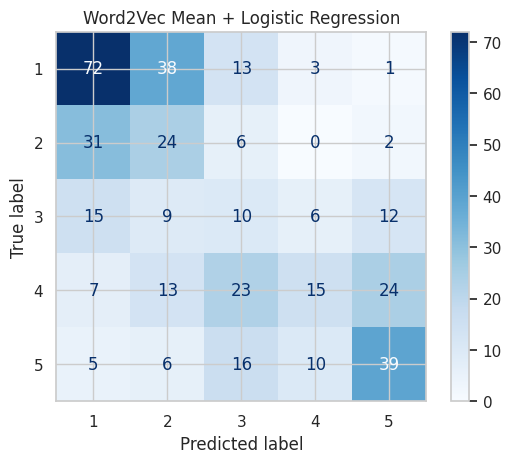

In [16]:
show_report(y_valid, y_pred_logreg_w2v)
show_confusion_matrix(y_valid, y_pred_logreg_w2v, "Word2Vec Mean + Logistic Regression")


## Preparing tokenized inputs for the neural baseline

You turn the reviews into padded token sequences and map the ratings to consecutive class IDs. This preprocessing stage is what allows the embedding model to train correctly without hard-coding assumptions about the available rating labels.

In [17]:
max_words = 20000
max_len = 150
embedding_dim = 128
batch_size = 32
epochs = 10

rating_labels = [int(x) for x in sorted(y_train.unique())]
label_to_id = {label: i for i, label in enumerate(rating_labels)}
id_to_rating = {i: label for i, label in enumerate(rating_labels)}
num_classes = int(len(rating_labels))

y_train_nn = y_train.map(label_to_id).to_numpy()
y_valid_nn = y_valid.map(label_to_id).to_numpy()

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_embed.tolist())

X_train_seq = tokenizer.texts_to_sequences(X_train_embed.tolist())
X_valid_seq = tokenizer.texts_to_sequences(X_valid_embed.tolist())

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_valid_pad = pad_sequences(X_valid_seq, maxlen=max_len, padding="post", truncating="post")

print(X_train_pad.shape, X_valid_pad.shape)
print(label_to_id)


(1600, 150) (400, 150)
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4}


## Training a lightweight neural classifier

You build a simple embedding-based network with pooling, a dense layer, and dropout. It is a reasonable neural baseline because it stays cheap to train while still testing whether a learned sequence representation helps beyond classical linear models.

In [18]:
def build_embedding_classifier(vocab_size, embedding_dim, max_len, num_classes):
    model = keras.Sequential(
        [
            layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
            layers.GlobalAveragePooling1D(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


embedding_model = build_embedding_classifier(max_words, embedding_dim, max_len, num_classes)
embedding_model.summary()

early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = embedding_model.fit(
    X_train_pad,
    y_train_nn,
    validation_data=(X_valid_pad, y_valid_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1,
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.3262 - loss: 1.5584 - val_accuracy: 0.3175 - val_loss: 1.5035
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3756 - loss: 1.4484 - val_accuracy: 0.4250 - val_loss: 1.4143
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4150 - loss: 1.3720 - val_accuracy: 0.4300 - val_loss: 1.3585
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4419 - loss: 1.2963 - val_accuracy: 0.4425 - val_loss: 1.2935
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4638 - loss: 1.2211 - val_accuracy: 0.4650 - val_loss: 1.2406
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4988 - loss: 1.1569 - val_accuracy: 0.4800 - val_loss: 1.1960
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5100 - loss: 1.1132 - val_accuracy: 0.5025 - val_loss: 1.1748
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5169 - loss: 1.0627 - val_accuracy: 0.5000 - val

## Plotting the training curves and scoring the neural model

You review the learning curves before trusting the validation score. That extra check helps you notice overfitting, unstable optimization, or a model that simply stops improving after a few epochs.

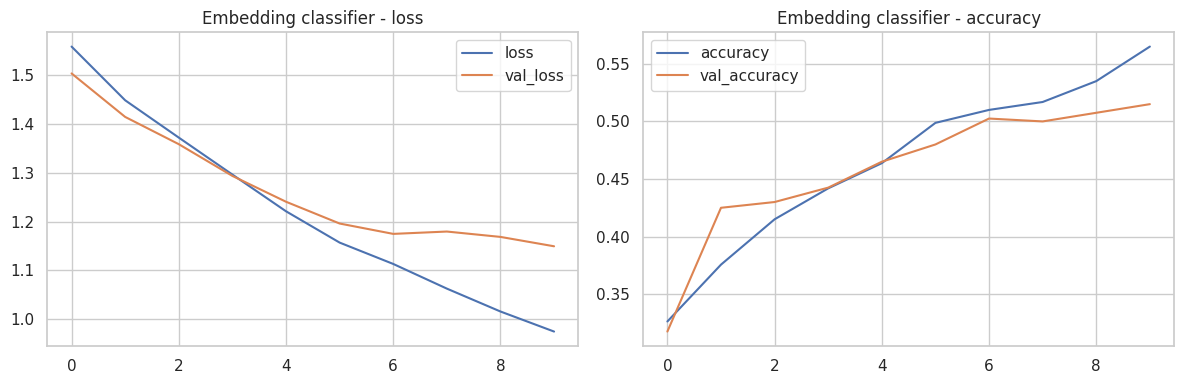

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


,Model,Accuracy,Macro_F1,Weighted_F1
0,Embedding Layer + Dense Network,0.515,0.42325,0.478462


In [19]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"{title} - loss")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"{title} - accuracy")
    plt.tight_layout()
    plt.show()


plot_history(history, "Embedding classifier")

y_pred_nn_ids = np.argmax(embedding_model.predict(X_valid_pad), axis=1)
y_pred_nn = pd.Series(y_pred_nn_ids, index=y_valid.index).map(id_to_rating)
results_nn, cm_nn = evaluate_classification("Embedding Layer + Dense Network", y_valid, y_pred_nn)
results_nn


## Studying the neural model errors

You compare the neural classifier's confusion matrix with the earlier TF-IDF models. What matters here is not only the overall score, but whether the network handles borderline ratings in a more sensible way.

              precision    recall  f1-score   support

           1       0.60      0.85      0.70       127
           2       0.50      0.22      0.31        63
           3       0.21      0.12      0.15        52
           4       0.45      0.35      0.40        82
           5       0.49      0.64      0.56        76

    accuracy                           0.52       400
   macro avg       0.45      0.44      0.42       400
weighted avg       0.48      0.52      0.48       400



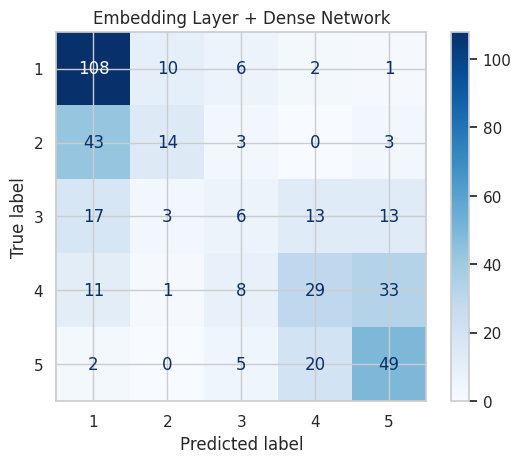

In [20]:
show_report(y_valid, y_pred_nn)
show_confusion_matrix(y_valid, y_pred_nn, "Embedding Layer + Dense Network")


## Preparing the DistilBERT datasets

You convert the reviews and labels into Hugging Face datasets and build the label mappings expected by the transformer stack. The pipeline is clean enough for a first transformer baseline, but it still stays deliberately lightweight, so the result should be read as an initial benchmark rather than as a fully optimized DistilBERT run.

In [21]:
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

bert_model_name = "distilbert-base-uncased"

# Integer mappings for training and evaluation.
label_to_id = {label: i for i, label in enumerate(rating_labels)}
id_to_rating = {i: label for i, label in enumerate(rating_labels)}

# String mappings for Hugging Face config serialization.
id_to_label_hf = {i: str(label) for i, label in enumerate(rating_labels)}
label_to_id_hf = {str(label): i for i, label in enumerate(rating_labels)}

bert_train_df = pd.DataFrame(
    {
        "text": X_train_embed.reset_index(drop=True),
        "label": pd.Series(y_train_nn),
    }
)
bert_valid_df = pd.DataFrame(
    {
        "text": X_valid_embed.reset_index(drop=True),
        "label": pd.Series(y_valid_nn),
    }
)

bert_train_dataset = Dataset.from_pandas(bert_train_df)
bert_valid_dataset = Dataset.from_pandas(bert_valid_df)

tokenizer_bert = AutoTokenizer.from_pretrained(bert_model_name)


def tokenize_function(batch):
    return tokenizer_bert(batch["text"], padding="max_length", truncation=True, max_length=128)


bert_train_dataset = bert_train_dataset.map(tokenize_function, batched=True)
bert_valid_dataset = bert_valid_dataset.map(tokenize_function, batched=True)

bert_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
bert_valid_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

## Configuring DistilBERT training

You instantiate the transformer model, define the evaluation metrics, and choose the training arguments. The setup is intentionally minimal: there is no evaluation at each epoch, no early stopping, and no checkpoint restoration for the best validation model. That makes the section easy to run, but it also means the comparison is based on the final state of training, not necessarily the strongest one DistilBERT could reach.

In [22]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=num_classes,
    id2label=id_to_label_hf,
    label2id=label_to_id_hf,
)


def compute_bert_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }


training_args = TrainingArguments(
    output_dir="./star_rating_distilbert_runs_v2",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_valid_dataset,
    compute_metrics=compute_bert_metrics,
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training and evaluating DistilBERT

You fine-tune DistilBERT, generate predictions on the shared validation split, and map the predicted IDs back to the original ratings. The score you get here is still useful, but it should be interpreted carefully because this run does not monitor validation quality during training and does not restore the best checkpoint afterward. In other words, you are comparing the last trained state, not a tuned best-version transformer baseline.

In [23]:
trainer.train()
trainer.evaluate()

bert_predictions = trainer.predict(bert_valid_dataset)
y_pred_bert_ids = np.argmax(bert_predictions.predictions, axis=1)
y_pred_bert = pd.Series(y_pred_bert_ids, index=y_valid.index).map(id_to_rating)

results_bert, cm_bert = evaluate_classification("DistilBERT", y_valid, y_pred_bert)
results_bert


Step,Training Loss
50,1.458841
100,1.177358
150,1.095030
200,1.036841


,Model,Accuracy,Macro_F1,Weighted_F1
0,DistilBERT,0.52,0.357335,0.428859


## Reading the DistilBERT confusion matrix

You inspect where the transformer helps and where it still struggles. If the confusion pattern looks disappointing, that does not automatically mean DistilBERT is a bad fit for the task: with this notebook, the transformer experiment is still a short baseline run, not a carefully monitored fine-tuning pipeline.

              precision    recall  f1-score   support

           1       0.58      0.97      0.72       127
           2       0.00      0.00      0.00        63
           3       0.67      0.08      0.14        52
           4       0.42      0.32      0.36        82
           5       0.46      0.72      0.56        76

    accuracy                           0.52       400
   macro avg       0.43      0.42      0.36       400
weighted avg       0.44      0.52      0.43       400



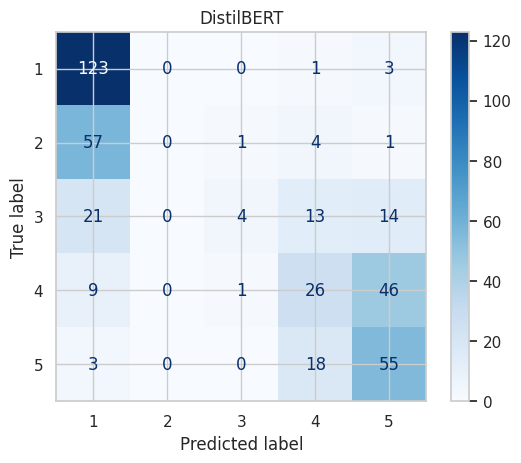

In [24]:
show_report(y_valid, y_pred_bert)
show_confusion_matrix(y_valid, y_pred_bert, "DistilBERT")


## Comparing every model side by side

You gather the regression and classification results into two summary tables. This gives you one clean place to rank the approaches and avoid drawing conclusions from scattered outputs across the notebook.

In [25]:
all_regression_results = pd.concat(results_regression, ignore_index=True).sort_values("RMSE")
all_classification_results = pd.concat(results_classification, ignore_index=True).sort_values(
    ["Macro_F1", "Accuracy"],
    ascending=False,
)

all_regression_results, all_classification_results


(                     Model       MAE      RMSE        R2
 1           TF-IDF + Ridge  0.795797  0.980060  0.591172
 2    Word2Vec Mean + Ridge  1.003013  1.199128  0.387979
 0  Baseline Mean Regressor  1.388031  1.532793 -0.000004,
                                  Model  Accuracy  Macro_F1  Weighted_F1
 4      Embedding Layer + Dense Network    0.5150  0.423250     0.478462
 1         TF-IDF + Logistic Regression    0.4675  0.410242     0.457621
 2                  TF-IDF + Linear SVM    0.4600  0.379374     0.437331
 3  Word2Vec Mean + Logistic Regression    0.4000  0.361164     0.398228
 5                           DistilBERT    0.5200  0.357335     0.428859
 0              Baseline Majority Class    0.3175  0.096395     0.153027)

## Visualizing the final benchmark

You turn the result tables into simple bar charts so the final takeaway is easier to present and discuss. These plots are especially useful when you need to explain the trade-off between performance and model complexity quickly.

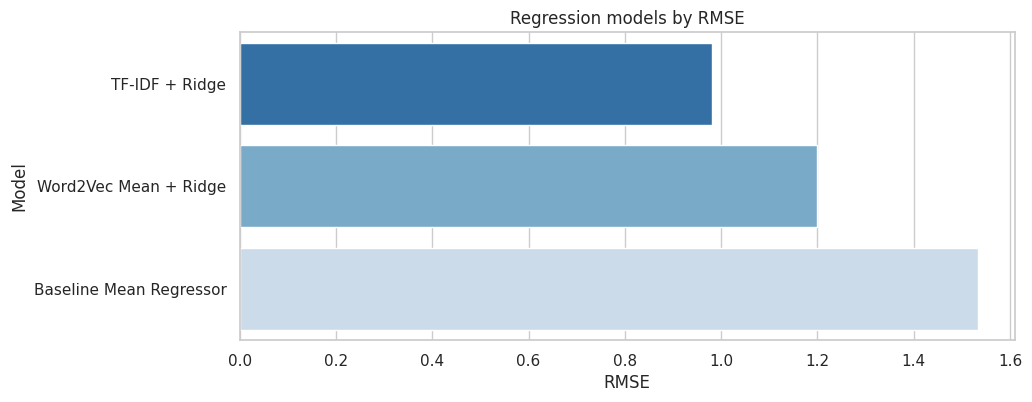

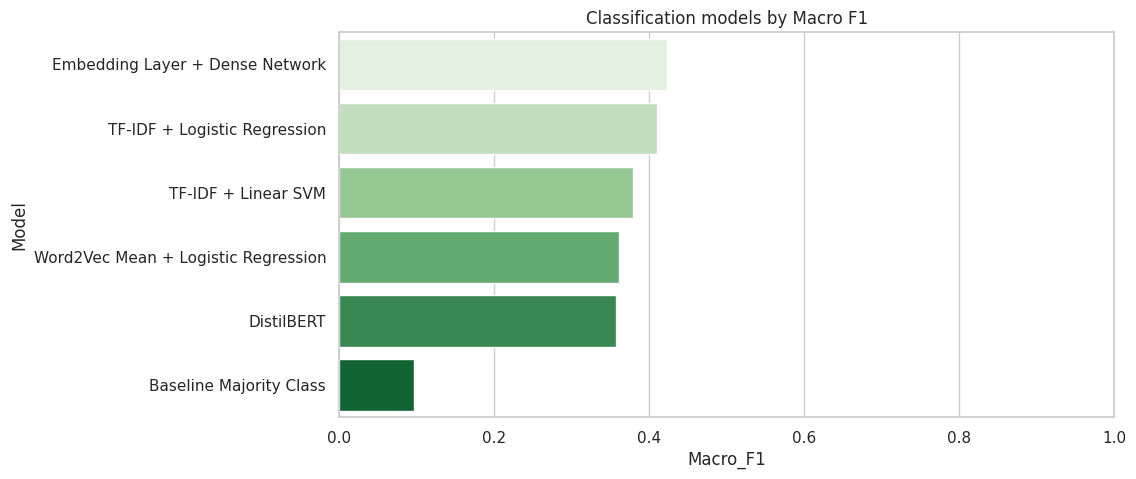

In [26]:
plt.figure(figsize=(10, 4))
sns.barplot(data=all_regression_results, x="RMSE", y="Model", palette="Blues_r")
plt.title("Regression models by RMSE")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=all_classification_results, x="Macro_F1", y="Model", palette="Greens")
plt.title("Classification models by Macro F1")
plt.xlim(0, 1)
plt.show()


## Global conclusion

The exact star-rating task is clearly harder than the binary sentiment task, and the results show that very clearly. On the regression side, `TF-IDF + Ridge` is the strongest option by a good margin, with the lowest RMSE (`0.980`) and the best `R2` (`0.591`). That means sparse lexical features capture the overall rating signal reasonably well when you let the model predict a continuous score. The Word2Vec regression baseline is weaker, and the mean regressor is far behind, so the TF-IDF representation is doing real work here.

On the exact 5-class classification side, the best validation result in this notebook comes from the `Embedding Layer + Dense Network`, with an accuracy of `0.515` and the best macro F1 (`0.423`). DistilBERT reaches a very similar accuracy (`0.520`), but its macro F1 is noticeably lower (`0.357`), which suggests that it does not handle the class balance as well and is probably less consistent across the five ratings. The TF-IDF classifiers remain competitive, especially Logistic Regression, but they do not beat the neural embedding model on the shared validation split.

If you need one model to keep for **exact class prediction**, the best choice from these recorded runs is **`Embedding Layer + Dense Network`**, because macro F1 matters more than raw accuracy on a 5-class imbalanced task. If you need the most reliable model for **rating estimation as a numeric signal**, then **`TF-IDF + Ridge`** is the better choice overall. In practical terms, this notebook suggests that the exact-label problem is still only moderately solved, and that simple well-structured baselines remain very hard to beat.